<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/1.set_periods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Export directory

In [2]:
exp_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Water Period Definitions"

# Import data

***Agência Nacional de Águas - ANA***/
Superintendência de Gestão da Rede Hidrometeorológica-SGH/
Sistema de Informações Hidrológicas - Versão WEB

- NivelConsistencia: 1 = Bruto, 2 = Consistido
- MediaDiaria: Indica se a medição é média diaria ou instantânea.  0 = Não , 1 = Sim
- TipoMedicaoCotas: 1 = Escala, 2 = Linígrafo, 3 = Data Logger, 5 = Escala SMS
- Status: 0 = Branco, 1 = Real, 2 = Estimado, 3 = Duvidoso, 4 = Régua Seca

Óbidos - Cotas\
`Código da Estação:17050001`

In [3]:
data_directory = "C:/Users/l_v_v/Documents/GitHub/time_series_curuai/datasets/HidroWeb"

In [4]:
#dados obidos = cotas
#eliminar dados duplicados para o mesmo dia
obidos = pd.read_csv(os.path.join(data_directory,'17050001_Cotas.csv')).drop_duplicates(subset=['Data'])
# obidos = pd.read_csv('/content/drive/MyDrive/CURUAI_PROCESS/17050001_Cotas.csv').drop_duplicates(subset=['Data'])
obidos = obidos[['EstacaoCodigo', 'Data',  'Maxima', 'Minima', 'Media' ]].copy()
obidos['Data'] = pd.to_datetime(obidos['Data'],dayfirst=True)
obidos['location'] = "Óbidos"
obidos = obidos.sort_values(by='Data').reset_index(drop=True)
obidos

,EstacaoCodigo,Data,Maxima,Minima,Media,location
0,17050001,1968-02-01,NaN,NaN,NaN,Óbidos
1,17050001,1968-03-01,478.0,401.0,436.0,Óbidos
2,17050001,1968-04-01,570.0,478.0,521.0,Óbidos
3,17050001,1968-05-01,646.0,575.0,621.0,Óbidos
4,17050001,1968-06-01,648.0,583.0,617.0,Óbidos
...,...,...,...,...,...,...
673,17050001,2025-03-01,684.0,548.0,625.0,Óbidos
674,17050001,2025-04-01,758.0,686.0,724.0,Óbidos
675,17050001,2025-05-01,778.0,760.0,773.0,Óbidos
676,17050001,2025-06-01,778.0,764.0,772.0,Óbidos


Curuai - Cotas\
`Código da Estação:17060000`

In [5]:
# dados curuai = cotas
#eliminar dados duplicados para o mesmo dia
# curuai = pd.read_csv('/content/drive/MyDrive/CURUAI_PROCESS/17060000_Cotas.csv').drop_duplicates(subset=['Data'])
curuai = pd.read_csv(os.path.join(data_directory,'17060000_Cotas.csv')).drop_duplicates(subset=['Data'])
curuai = curuai[['EstacaoCodigo', 'Data',  'Maxima', 'Minima', 'Media' ]].copy()
curuai['Data'] = pd.to_datetime(curuai['Data'],dayfirst=True)
curuai['location'] = "Curuai"
curuai = curuai.sort_values(by='Data').reset_index(drop=True)
curuai

,EstacaoCodigo,Data,Maxima,Minima,Media,location
0,17060000,1982-09-01,789.0,609.0,711.0,Curuai
1,17060000,1982-10-01,NaN,NaN,NaN,Curuai
2,17060000,1982-11-01,NaN,NaN,NaN,Curuai
3,17060000,1982-12-01,590.0,489.0,540.0,Curuai
4,17060000,1983-01-01,693.0,597.0,649.0,Curuai
...,...,...,...,...,...,...
418,17060000,2018-11-01,461.0,418.0,431.0,Curuai
419,17060000,2018-12-01,682.0,465.0,569.0,Curuai
420,17060000,2019-01-01,805.0,683.0,747.0,Curuai
421,17060000,2019-02-01,904.0,805.0,848.0,Curuai


In [6]:
# concatenar dados das duas estações e restringir para o periodo de tempo que há dados em curuai
cotas = obidos.merge(curuai,on="Data", how = 'right', suffixes=('_obidos','_curuai'))
cotas

,EstacaoCodigo_obidos,Data,Maxima_obidos,Minima_obidos,Media_obidos,location_obidos,EstacaoCodigo_curuai,Maxima_curuai,Minima_curuai,Media_curuai,location_curuai
0,17050001,1982-09-01,514.0,315.0,425.0,Óbidos,17060000,789.0,609.0,711.0,Curuai
1,17050001,1982-10-01,308.0,142.0,217.0,Óbidos,17060000,NaN,NaN,NaN,Curuai
2,17050001,1982-11-01,176.0,143.0,155.0,Óbidos,17060000,NaN,NaN,NaN,Curuai
3,17050001,1982-12-01,311.0,184.0,246.0,Óbidos,17060000,590.0,489.0,540.0,Curuai
4,17050001,1983-01-01,409.0,318.0,366.0,Óbidos,17060000,693.0,597.0,649.0,Curuai
...,...,...,...,...,...,...,...,...,...,...,...
418,17050001,2018-11-01,162.0,90.0,112.0,Óbidos,17060000,461.0,418.0,431.0,Curuai
419,17050001,2018-12-01,407.0,170.0,301.0,Óbidos,17060000,682.0,465.0,569.0,Curuai
420,17050001,2019-01-01,529.0,410.0,473.0,Óbidos,17060000,805.0,683.0,747.0,Curuai
421,17050001,2019-02-01,634.0,530.0,577.0,Óbidos,17060000,904.0,805.0,848.0,Curuai


In [7]:
# reajustar indices da tabela para gerar gráfico
cotas = cotas.reset_index(drop=True).dropna()
cotas = cotas[['Maxima_obidos', 'Minima_obidos', 'Media_obidos',
        'Maxima_curuai', 'Minima_curuai', 'Media_curuai']]
cotas.columns = ['Max Óbidos', 'Min Óbidos', 'Mean Óbidos',
        'Max Curuai', 'Min Curuai', 'Mean Curuai']


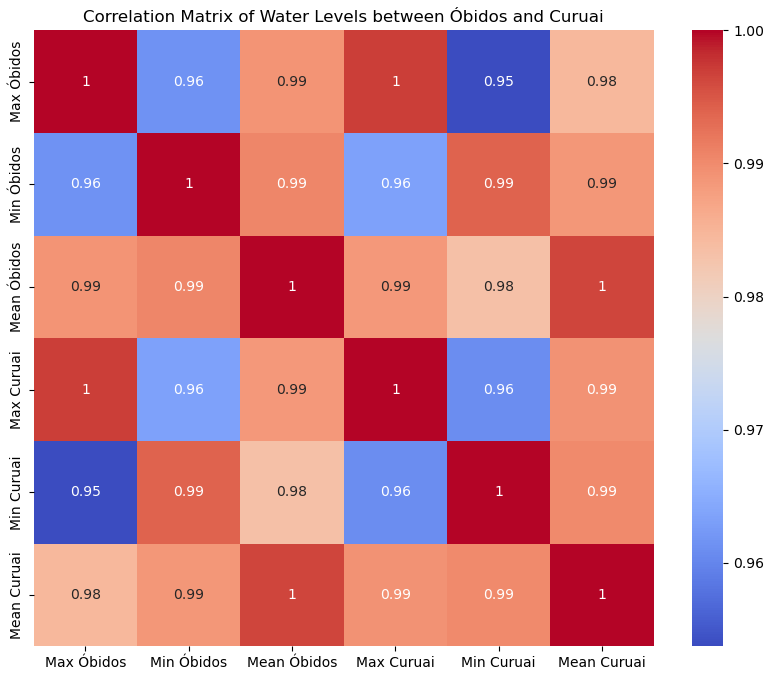

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(cotas.corr(), annot=True, cmap='coolwarm')
plt.savefig(os.path.join(exp_directory, 'correlation_matrix.png'),dpi=300)
plt.title('Correlation Matrix of Water Levels between Óbidos and Curuai')
plt.show()

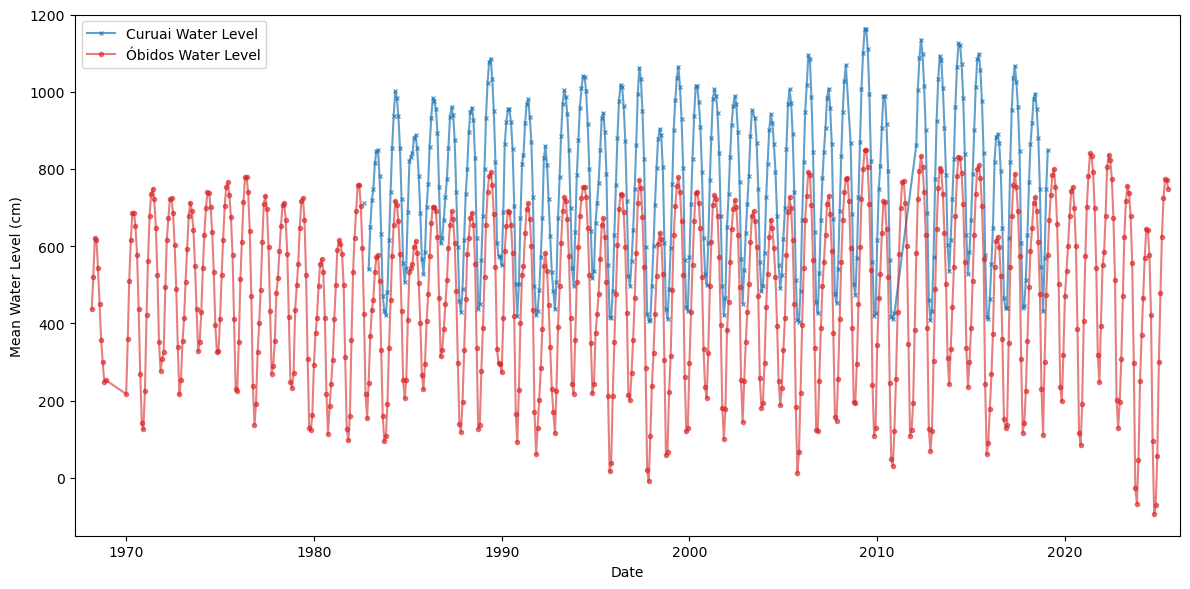

In [9]:
#comparar dados = seguem o mesmo padrão, aproximadamente
# grafico de linhas


fig, ax = plt.subplots(figsize=(12, 6))

    # Plot predictions
ax.plot(curuai['Data'], curuai['Media'],
            color='#1f77b4',marker="x",markersize = 2.5,  linestyle='solid', linewidth=1.5, alpha=0.7, label='Curuai Water Level')
ax.plot(obidos['Data'], obidos['Media'],
            color='#d62728', marker="o",markersize = 3,linestyle='solid', linewidth=1.5, alpha=0.6, label='Óbidos Water Level')
# media = [float(obidos["Media"].mean())] * len(obidos["Media"])
# ax.plot(obidos['Data'],media,color='grey', linestyle='--', linewidth=1.5, alpha=0.7, label='Óbidos Mean Water Level')
# media = [float(obidos["Media"].mean() + ( obidos["Media"].std()))] * len(obidos["Media"])
# ax.plot(obidos['Data'],media,color='grey', linestyle='-.', linewidth=1.5, alpha=0.7, label='High/Low Water Level Limit' )
# media = [float(obidos["Media"].mean() - ( obidos["Media"].std()))] * len(obidos["Media"])
# ax.plot(obidos['Data'],media,color='grey', linestyle='-.', linewidth=1.5, alpha=0.7 )

ax.set_xlabel('Date')
ax.set_ylabel('Mean Water Level (cm)')
ax.legend(loc='upper left')
ax.set_ylim(-150,1200)
ax.set_xlim(left = -1000,right=20500)
plt.tight_layout()
plt.savefig(os.path.join(exp_directory,f"time_series.jpg"),dpi=300)
plt.show()
plt.close()

In [10]:
print('media obidos: ', obidos["Media"].mean())
print('std obidos: ', obidos["Media"].std())
print('obidos lim superior: ', obidos["Media"].mean() + ( obidos["Media"].std()))
print('obidos lim inferior: ', obidos["Media"].mean() - (obidos["Media"].std()))

media obidos:  481.9778434268833
std obidos:  216.0108432917262
obidos lim superior:  697.9886867186094
obidos lim inferior:  265.9670001351571


# Classify Periods

In [11]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

# --- CONFIGURATION ---
# 1. Set your DataFrame variable name here (e.g. df, obidos_att)
target_df = obidos  # <--- CHANGE THIS if your dataframe is named 'df'

# 2. Set your column names
col_level = 'Media'   # Column with water levels
col_date = 'Data'     # Column with dates
# ---------------------

# Ensure dates are datetime objects
target_df[col_date] = pd.to_datetime(target_df[col_date])

# Find Peaks (High Water) and Valleys (Low Water)
# Note: distance=150 is an approximate 5-month gap to avoid micro-fluctuations
peaks_indices, _ = find_peaks(target_df[col_level], distance=10)
valleys_indices, _ = find_peaks(-target_df[col_level], distance=10)

# Extract DataFrames using integer locations (iloc)
df_peaks = target_df.iloc[peaks_indices].copy()
df_peaks['water_period'] = 'HW'

df_valleys = target_df.iloc[valleys_indices].copy()
df_valleys['water_period'] = 'LW'

# Combine and Sort Chronologically
critical_points = pd.concat([df_peaks, df_valleys])
critical_points[col_date] = pd.to_datetime(critical_points[col_date])
critical_points = critical_points.sort_values(by=col_date).reset_index(drop=True)

critical_points['next'] = critical_points['Data'].shift(-1)
critical_points['previous'] = critical_points['Data'].shift(+1)

critical_points['lim_next'] = critical_points['Data'] + ((critical_points['next'] - critical_points['Data'])/4)
critical_points['lim_previous'] = critical_points['Data'] - ((critical_points['Data']- critical_points['previous'] )/4)

# Define Periods (Rising vs Falling)
period_limits = []

for i in range(len(critical_points) - 1):
    start_date = critical_points.loc[i, 'lim_next']
    end_date = critical_points.loc[i+1, 'lim_previous']
    
    current_type = critical_points.loc[i, 'water_period']
    next_type = critical_points.loc[i+1, 'water_period']
    
    # Determine period classification
    if current_type == 'LW' and next_type == 'HW':
        classification = "R"
    elif current_type == 'HW' and next_type == 'LW':
        classification = "F"
    else:
        # Transition/Double peak cases
        classification = f"{current_type}_Transition"

    period_limits.append({
        'lim_previous': start_date,
        'lim_next': end_date,
        'water_period': classification,
    })

# Create final DataFrame
df_period_limits = pd.DataFrame(period_limits)

print("Classification complete. First 5 periods:")
display(df_period_limits.tail(20))

# # Save to CSV for the next notebook
# import os
# # Ensure 'wrk_directory' is defined, otherwise use current folder '.'
# output_dir = wrk_directory if 'wrk_directory' in globals() else '.'
# 
# print("File 'water_period_limits.csv' saved successfully.")

Classification complete. First 5 periods:


,lim_previous,lim_next,water_period
92,2015-07-09 06:00:00,2015-09-23 18:00:00,F
93,2015-12-24 06:00:00,2016-04-08 18:00:00,R
94,2016-07-09 06:00:00,2016-09-23 18:00:00,F
95,2016-12-16 06:00:00,2017-03-16 18:00:00,R
96,2017-06-08 06:00:00,2017-08-23 18:00:00,F
97,2017-11-30 18:00:00,2018-04-01 06:00:00,R
98,2018-07-09 06:00:00,2018-09-23 18:00:00,F
99,2018-12-24 00:00:00,2019-04-09 00:00:00,R
100,2019-07-09 06:00:00,2019-09-23 18:00:00,F
101,2019-12-24 06:00:00,2020-04-08 18:00:00,R


In [12]:
period_limits = df_period_limits.merge(critical_points[['lim_previous',	'lim_next',	'water_period']], on= ['lim_previous',	'lim_next',	'water_period'],how='outer')

In [17]:
period_limits

,lim_previous,lim_next,water_period
0,NaT,1968-09-30 12:00:00,HW
1,1968-09-30 12:00:00,1969-08-01 12:00:00,F
2,1969-08-01 12:00:00,1970-02-07 18:00:00,LW
3,1970-02-07 18:00:00,1970-04-24 06:00:00,R
4,1970-04-24 06:00:00,1970-07-16 18:00:00,HW
...,...,...,...
220,2024-03-16 12:00:00,2024-06-08 06:00:00,HW
221,2024-06-08 06:00:00,2024-08-23 18:00:00,F
222,2024-08-23 18:00:00,2024-11-23 00:00:00,LW
223,2024-11-23 00:00:00,2025-03-09 00:00:00,R


In [16]:
critical_points

,EstacaoCodigo,Data,Maxima,Minima,Media,location,water_period,next,previous,lim_next,lim_previous
0,17050001,1968-05-01,646.0,575.0,621.0,Óbidos,HW,1970-01-01,NaT,1968-09-30 12:00:00,NaT
1,17050001,1970-01-01,300.0,144.0,217.0,Óbidos,LW,1970-06-01,1968-05-01,1970-02-07 18:00:00,1969-08-01 12:00:00
2,17050001,1970-06-01,693.0,676.0,686.0,Óbidos,HW,1970-12-01,1970-01-01,1970-07-16 18:00:00,1970-04-24 06:00:00
3,17050001,1970-12-01,147.0,110.0,126.0,Óbidos,LW,1971-06-01,1970-06-01,1971-01-15 12:00:00,1970-10-16 06:00:00
4,17050001,1971-06-01,757.0,741.0,749.0,Óbidos,HW,1971-11-01,1970-12-01,1971-07-09 06:00:00,1971-04-16 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...
108,17050001,2023-05-01,764.0,742.0,756.0,Óbidos,HW,2023-11-01,2022-11-01,2023-06-16 00:00:00,2023-03-16 18:00:00
109,17050001,2023-11-01,-18.0,-90.0,-67.0,Óbidos,LW,2024-05-01,2023-05-01,2023-12-16 12:00:00,2023-09-16 00:00:00
110,17050001,2024-05-01,656.0,630.0,645.0,Óbidos,HW,2024-10-01,2023-11-01,2024-06-08 06:00:00,2024-03-16 12:00:00
111,17050001,2024-10-01,-64.0,-128.0,-94.0,Óbidos,LW,2025-05-01,2024-05-01,2024-11-23 00:00:00,2024-08-23 18:00:00


In [14]:
period_limits.to_csv(os.path.join(exp_directory, 'water_period_limits.csv'))

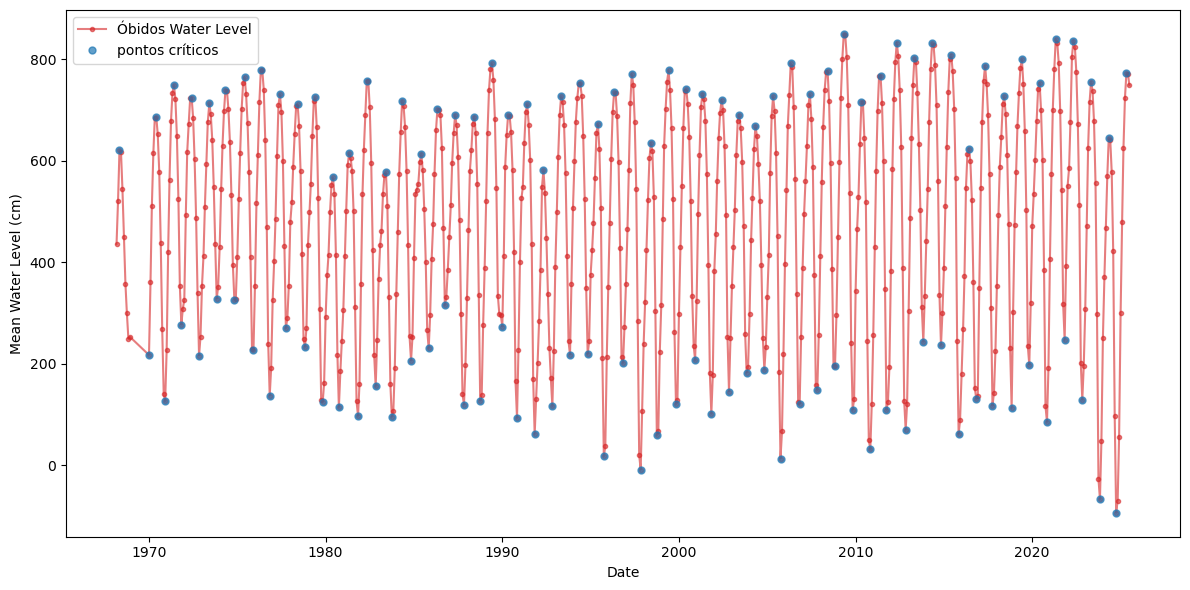

In [15]:
#comparar dados = seguem o mesmo padrão, aproximadamente
# grafico de linhas


fig, ax = plt.subplots(figsize=(12, 6))

    # Plot predictions

ax.plot(obidos['Data'], obidos['Media'],
            color='#d62728', marker="o",markersize = 3,linestyle='solid', linewidth=1.5, alpha=0.6, label='Óbidos Water Level')

ax.plot(critical_points['Data'],critical_points['Media'], linestyle='None', marker="o",markersize = 5, alpha=0.7, label='pontos críticos')

ax.set_xlabel('Date')
ax.set_ylabel('Mean Water Level (cm)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()
plt.close()